In [18]:
import pandas as pd
import numpy as np
import os

# 1. Download dataset from Kaggle (works in Colab, Jupyter, or any environment)
import kagglehub

path = kagglehub.dataset_download("rabieelkharoua/parkinsons-disease-dataset-analysis")
print("Path to dataset files:", path)

# 2. List files in the downloaded folder to find the CSV name
print("Files found:", os.listdir(path))

# 3. Load the CSV file (update filename based on the output above)
df = pd.read_csv(f"{path}/parkinsons_disease_data.csv")
df.head()

Using Colab cache for faster access to the 'parkinsons-disease-dataset-analysis' dataset.
Path to dataset files: /kaggle/input/parkinsons-disease-dataset-analysis
Files found: ['parkinsons_disease_data.csv']


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [19]:
df = pd.read_csv(f"{path}/parkinsons_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [20]:
print("DATASET SHAPE:")
print(df.shape)

print("FIRST 5 ROWS (HEAD):")
print(df.head())

print("LAST 5 ROWS (TAIL):")
print(df.tail())

print("DATASET INFO (dtypes + nulls):")
print(df.info())

print("STATISTICAL SUMMARY:")
print(df.describe())

print("NULL VALUES PER COLUMN:")
print(df.isnull().sum())

print("DUPLICATE ROWS:")
print(df.duplicated().sum())

print("COLUMN NAMES:")
print(df.columns.tolist())

DATASET SHAPE:
(2105, 35)
FIRST 5 ROWS (HEAD):
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       3058   85       0          3               1  19.619878        0   
1       3059   75       0          0               2  16.247339        1   
2       3060   70       1          0               0  15.368239        0   
3       3061   52       0          0               0  15.454557        0   
4       3062   87       0          0               1  18.616042        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  \
0            5.108241          1.380660     3.893969  ...   
1            6.027648          8.409804     8.513428  ...   
2            2.242135          0.213275     6.498805  ...   
3            5.997788          1.375045     6.715033  ...   
4            9.775243          1.188607     4.657572  ...   

   FunctionalAssessment  Tremor  Rigidity  Bradykinesia  PosturalInstability  \
0              1.572427       1         0        

In [21]:
import pandas as pd
import numpy as np

# Step 1: Dataset load
df = pd.read_csv(f"{path}/parkinsons_disease_data.csv")
print("Original Shape:", df.shape)

# Step 2: Useless columns drop
df.drop(columns=['PatientID', 'DoctorInCharge'], inplace=True, errors='ignore')
print("After Dropping ID Columns:", df.shape)

# Step 3: Duplicates remove
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Duplicates Removed: {before - df.shape[0]}")
print("After Duplicates Remove:", df.shape)

# Step 4: Missing values
print("\nMissing Values:")
print(df.isnull().sum())
df.dropna(inplace=True)
print("After Missing Values Remove:", df.shape)

# Step 5: Outliers remove - sirf continuous columns par
categorical_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'AlcoholConsumption', 'FamilyHistoryParkinsons',
    'TraumaticBrainInjury', 'Hypertension', 'Diabetes',
    'Depression', 'Stroke', 'Tremor', 'Rigidity',
    'Bradykinesia', 'PosturalInstability', 'SpeechProblems',
    'Diagnosis'
]

continuous_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in categorical_cols
]

Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df[continuous_cols] < lower) | (df[continuous_cols] > upper)).any(axis=1)
df = df[mask]
print("After Outliers Remove:", df.shape)

# Step 6: Final checks
print("\nDATASET SHAPE:", df.shape)
print("\nCLASS DISTRIBUTION:")
print(df['Diagnosis'].value_counts())
print("\nSTATISTICAL SUMMARY:")
print(df.describe())
print("\nNULL VALUES:")
print(df.isnull().sum())
print("\nDUPLICATE ROWS:", df.duplicated().sum())

# Step 7: Clean dataset save
df.to_csv("clean_parkinsons_dataset.csv", index=False)
print("\nClean dataset saved!")

Original Shape: (2105, 35)
After Dropping ID Columns: (2105, 33)
Duplicates Removed: 0
After Duplicates Remove: (2105, 33)

Missing Values:
Age                         0
Gender                      0
Ethnicity                   0
EducationLevel              0
BMI                         0
Smoking                     0
AlcoholConsumption          0
PhysicalActivity            0
DietQuality                 0
SleepQuality                0
FamilyHistoryParkinsons     0
TraumaticBrainInjury        0
Hypertension                0
Diabetes                    0
Depression                  0
Stroke                      0
SystolicBP                  0
DiastolicBP                 0
CholesterolTotal            0
CholesterolLDL              0
CholesterolHDL              0
CholesterolTriglycerides    0
UPDRS                       0
MoCA                        0
FunctionalAssessment        0
Tremor                      0
Rigidity                    0
Bradykinesia                0
PosturalInstability 

DATASET SHAPE: (1589, 33)

COLUMN NAMES:
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension', 'Diabetes', 'Depression', 'Stroke', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'UPDRS', 'MoCA', 'FunctionalAssessment', 'Tremor', 'Rigidity', 'Bradykinesia', 'PosturalInstability', 'SpeechProblems', 'SleepDisorders', 'Constipation', 'Diagnosis']

DATATYPES:
Age                           int64
Gender                        int64
Ethnicity                     int64
EducationLevel                int64
BMI                         float64
Smoking                       int64
AlcoholConsumption          float64
PhysicalActivity            float64
DietQuality                 float64
SleepQuality                float64
FamilyHistoryParkinsons       int64
TraumaticBrainInjury        

/tmp/ipykernel_1845/2495508742.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='Set2')


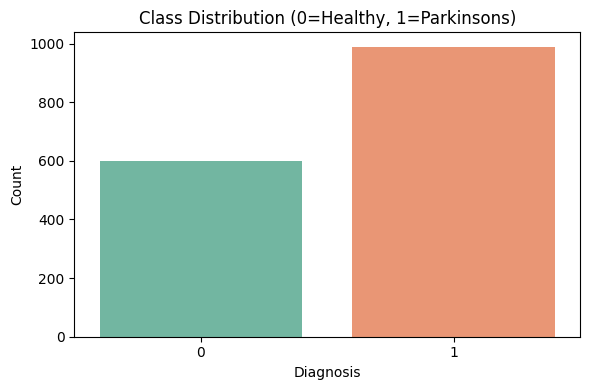


MISSING VALUES:
Age                         0
Gender                      0
Ethnicity                   0
EducationLevel              0
BMI                         0
Smoking                     0
AlcoholConsumption          0
PhysicalActivity            0
DietQuality                 0
SleepQuality                0
FamilyHistoryParkinsons     0
TraumaticBrainInjury        0
Hypertension                0
Diabetes                    0
Depression                  0
Stroke                      0
SystolicBP                  0
DiastolicBP                 0
CholesterolTotal            0
CholesterolLDL              0
CholesterolHDL              0
CholesterolTriglycerides    0
UPDRS                       0
MoCA                        0
FunctionalAssessment        0
Tremor                      0
Rigidity                    0
Bradykinesia                0
PosturalInstability         0
SpeechProblems              0
SleepDisorders              0
Constipation                0
Diagnosis              

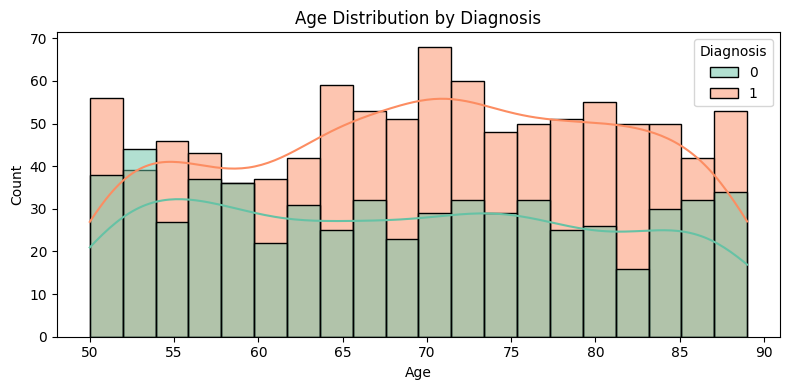

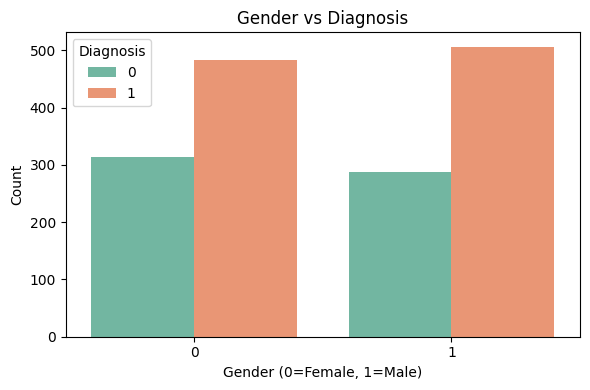

/tmp/ipykernel_1845/2495508742.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y='BMI', data=df, palette='Set2')


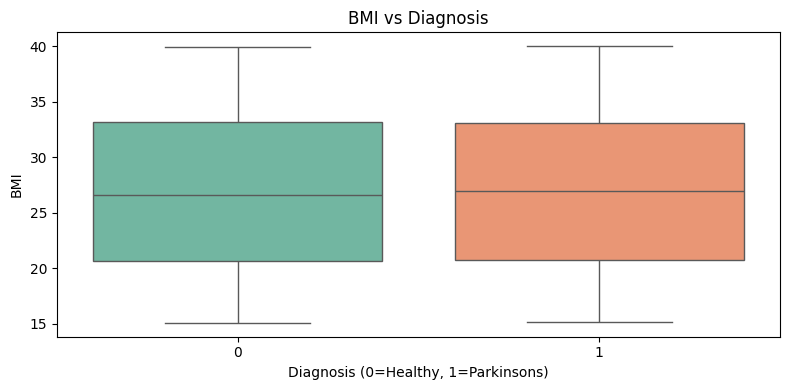

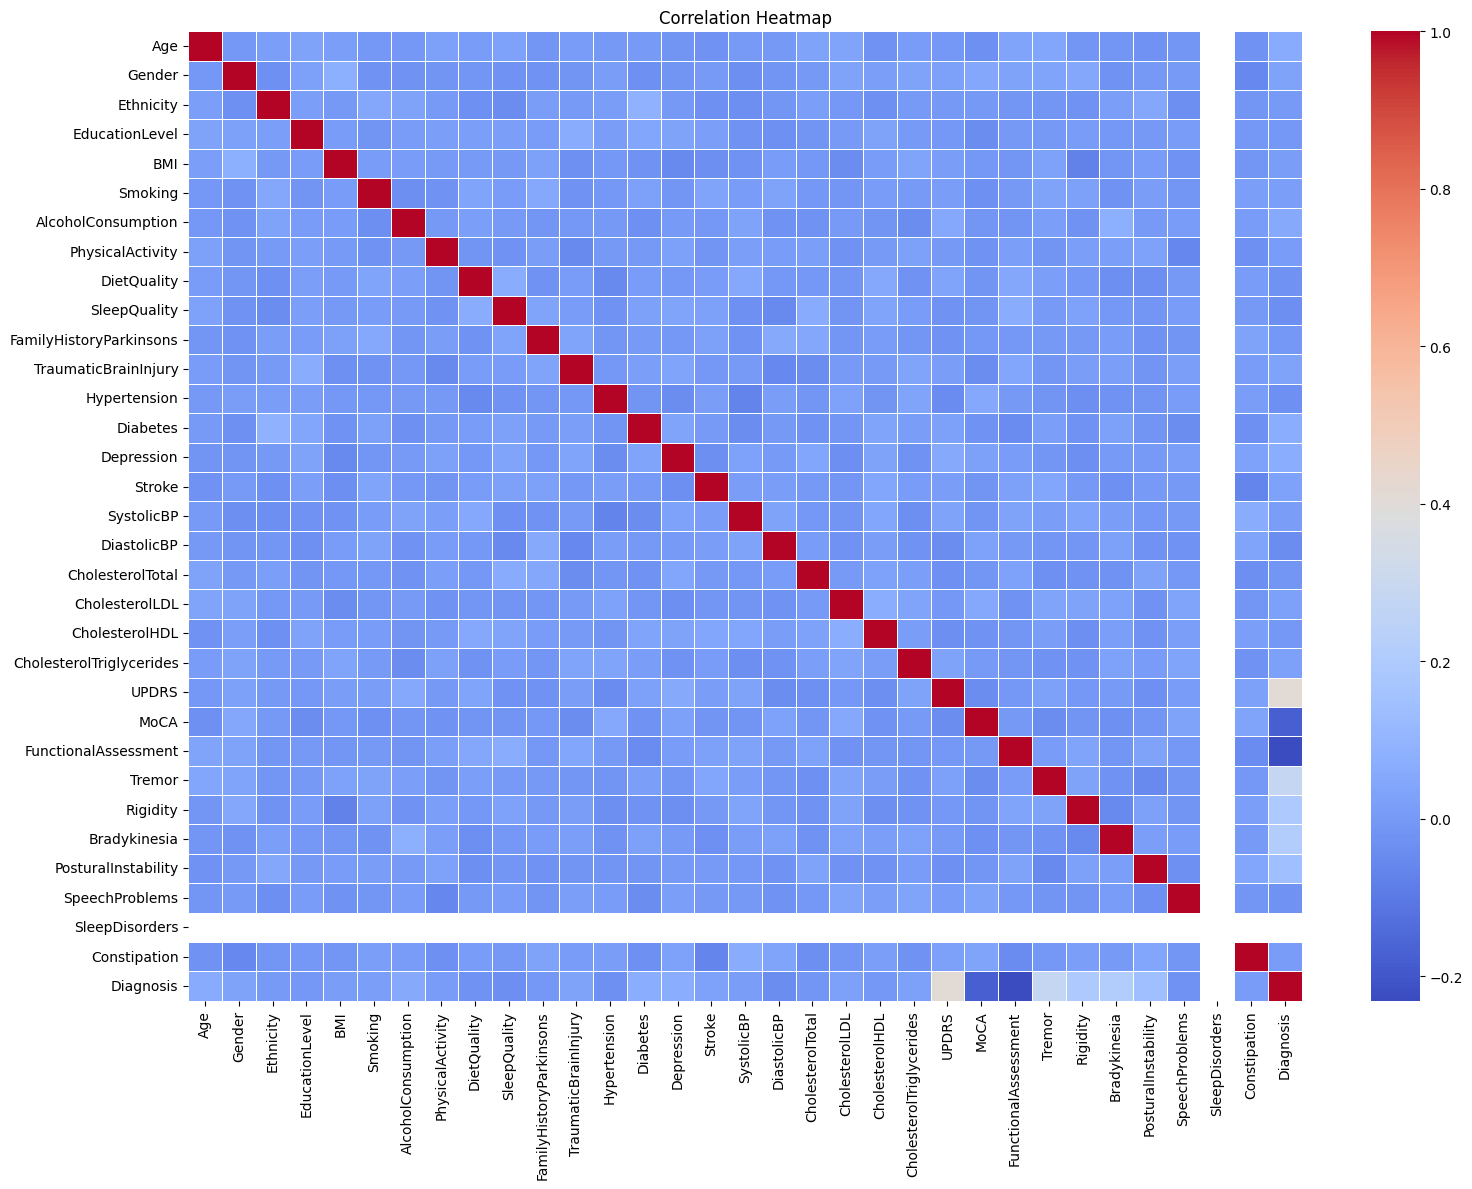


TOP CORRELATIONS WITH DIAGNOSIS:
UPDRS                   0.411359
Tremor                  0.279742
FunctionalAssessment    0.230780
Bradykinesia            0.208579
Rigidity                0.191807
MoCA                    0.177653
PosturalInstability     0.141054
Depression              0.069730
Diabetes                0.069652
Age                     0.062042
AlcoholConsumption      0.057613
DiastolicBP             0.039017
SleepQuality            0.037289
Gender                  0.032282
Hypertension            0.031531
Name: Diagnosis, dtype: float64


/tmp/ipykernel_1845/2495508742.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y='UPDRS', data=df, palette='Set2')


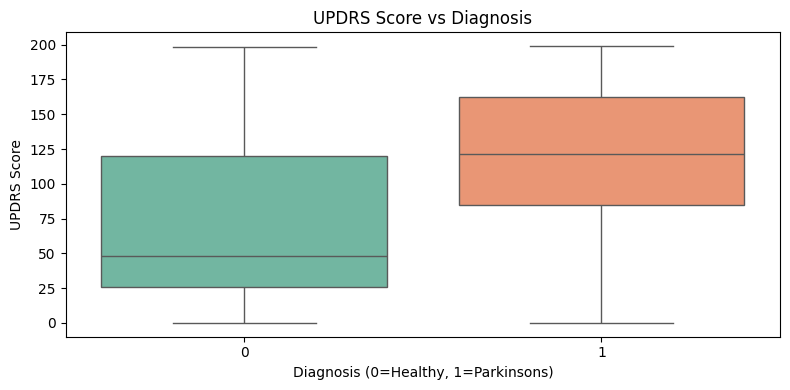


SYMPTOM MEANS BY DIAGNOSIS:
             Tremor  Rigidity  Bradykinesia  PosturalInstability  \
Diagnosis                                                          
0          0.246667  0.140000      0.095000             0.080000   
1          0.531850  0.310415      0.267947             0.182002   

           SpeechProblems  
Diagnosis                  
0                0.306667  
1                0.285137  


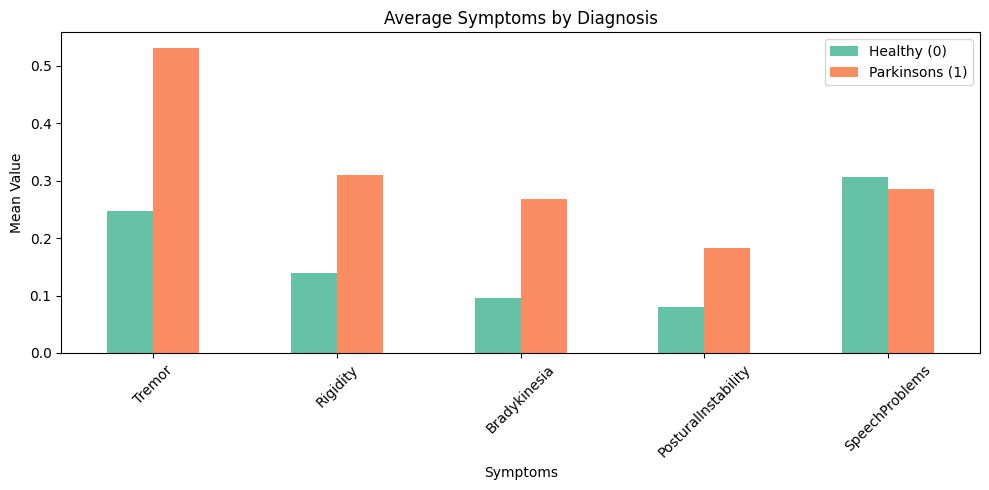

/tmp/ipykernel_1845/2495508742.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=col, data=df,
/tmp/ipykernel_1845/2495508742.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=col, data=df,
/tmp/ipykernel_1845/2495508742.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y=col, data=df,
/tmp/ipykernel_1845/2495508742.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

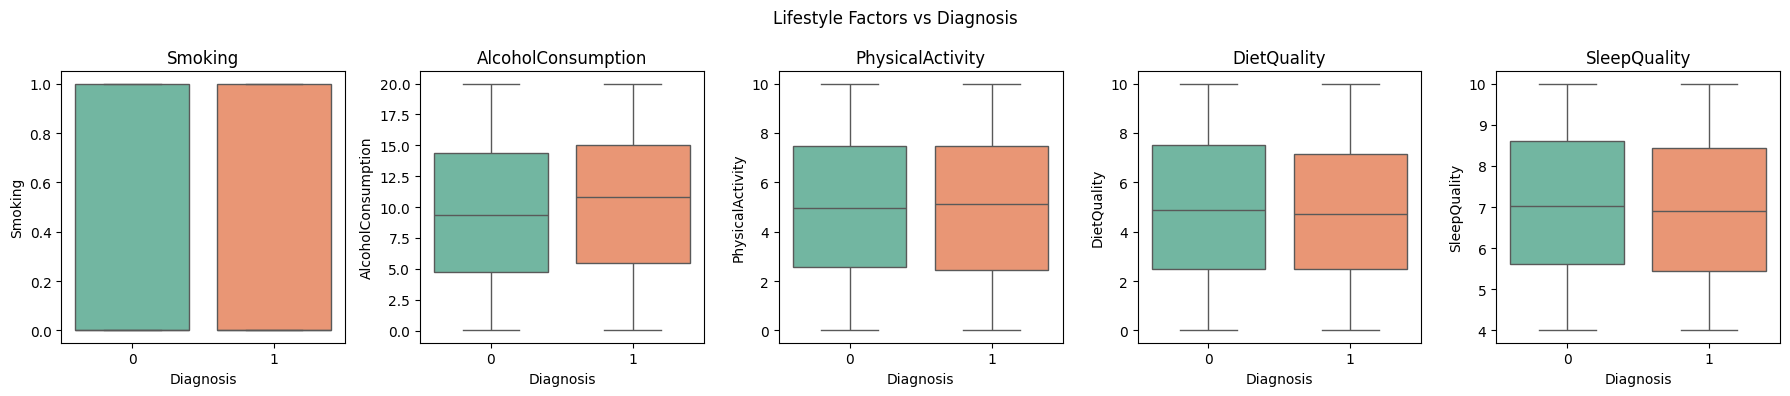

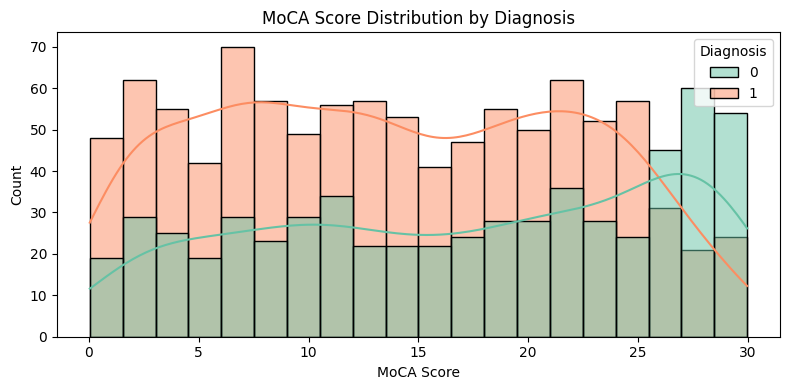


EDA Complete!


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load clean dataset
df = pd.read_csv('clean_parkinsons_dataset.csv')

# ================================
# EDA 1: Basic Info
# ================================
print("DATASET SHAPE:", df.shape)
print("\nCOLUMN NAMES:")
print(df.columns.tolist())
print("\nDATATYPES:")
print(df.dtypes)
print("\nFIRST 5 ROWS:")
print(df.head())
print("\nSTATISTICAL SUMMARY:")
print(df.describe())

# ================================
# EDA 2: Class Distribution
# ================================
print("\nCLASS DISTRIBUTION:")
print(df['Diagnosis'].value_counts())
print(df['Diagnosis'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title('Class Distribution (0=Healthy, 1=Parkinsons)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ================================
# EDA 3: Missing Values
# ================================
print("\nMISSING VALUES:")
print(df.isnull().sum())

# ================================
# EDA 4: Age Distribution
# ================================
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Diagnosis',
             kde=True, palette='Set2', bins=20)
plt.title('Age Distribution by Diagnosis')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ================================
# EDA 5: Gender vs Diagnosis
# ================================
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Diagnosis', data=df, palette='Set2')
plt.title('Gender vs Diagnosis')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ================================
# EDA 6: BMI Distribution
# ================================
plt.figure(figsize=(8, 4))
sns.boxplot(x='Diagnosis', y='BMI', data=df, palette='Set2')
plt.title('BMI vs Diagnosis')
plt.xlabel('Diagnosis (0=Healthy, 1=Parkinsons)')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

# ================================
# EDA 7: Correlation Heatmap
# ================================
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm',
            linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# ================================
# EDA 8: Top Correlations with Diagnosis
# ================================
print("\nTOP CORRELATIONS WITH DIAGNOSIS:")
corr_target = df.corr()['Diagnosis'].drop('Diagnosis')
print(corr_target.abs().sort_values(ascending=False).head(15))

# ================================
# EDA 9: UPDRS vs Diagnosis
# ================================
plt.figure(figsize=(8, 4))
sns.boxplot(x='Diagnosis', y='UPDRS', data=df, palette='Set2')
plt.title('UPDRS Score vs Diagnosis')
plt.xlabel('Diagnosis (0=Healthy, 1=Parkinsons)')
plt.ylabel('UPDRS Score')
plt.tight_layout()
plt.show()

# ================================
# EDA 10: Symptoms vs Diagnosis
# ================================
symptom_cols = ['Tremor', 'Rigidity', 'Bradykinesia',
                'PosturalInstability', 'SpeechProblems']

symptom_means = df.groupby('Diagnosis')[symptom_cols].mean()
print("\nSYMPTOM MEANS BY DIAGNOSIS:")
print(symptom_means)

symptom_means.T.plot(kind='bar', figsize=(10, 5),
                      color=['#66c2a5', '#fc8d62'])
plt.title('Average Symptoms by Diagnosis')
plt.xlabel('Symptoms')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(['Healthy (0)', 'Parkinsons (1)'])
plt.tight_layout()
plt.show()

# ================================
# EDA 11: Lifestyle Factors
# ================================
lifestyle_cols = ['Smoking', 'AlcoholConsumption',
                  'PhysicalActivity', 'DietQuality', 'SleepQuality']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(lifestyle_cols):
    sns.boxplot(x='Diagnosis', y=col, data=df,
                palette='Set2', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Diagnosis')
plt.suptitle('Lifestyle Factors vs Diagnosis')
plt.tight_layout()
plt.show()

# ================================
# EDA 12: MoCA vs Diagnosis
# ================================
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='MoCA', hue='Diagnosis',
             kde=True, palette='Set2', bins=20)
plt.title('MoCA Score Distribution by Diagnosis')
plt.xlabel('MoCA Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nEDA Complete!")

In [23]:
# Insights

print("Class Distribution:")
print(df['Diagnosis'].value_counts())

print("\nAverage Age by Diagnosis:")
print(df.groupby('Diagnosis')['Age'].mean().round(1))

print("\nAverage UPDRS by Diagnosis:")
print(df.groupby('Diagnosis')['UPDRS'].mean().round(2))

print("\nTop 5 Features Correlated with Diagnosis:")
corr = df.corr()['Diagnosis'].drop('Diagnosis')
print(corr.abs().sort_values(ascending=False).head(5).round(4))

Class Distribution:
Diagnosis
1    989
0    600
Name: count, dtype: int64

Average Age by Diagnosis:
Diagnosis
0    68.5
1    70.0
Name: Age, dtype: float64

Average UPDRS by Diagnosis:
Diagnosis
0     72.04
1    120.46
Name: UPDRS, dtype: float64

Top 5 Features Correlated with Diagnosis:
UPDRS                   0.4114
Tremor                  0.2797
FunctionalAssessment    0.2308
Bradykinesia            0.2086
Rigidity                0.1918
Name: Diagnosis, dtype: float64


In [24]:
print(df['Diagnosis'].value_counts())
print(df['Diagnosis'].value_counts(normalize=True) * 100)

Diagnosis
1    989
0    600
Name: count, dtype: int64
Diagnosis
1    62.240403
0    37.759597
Name: proportion, dtype: float64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features aur Target
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

Train Shape: (1271, 32)
Test Shape: (318, 32)



Logistic Regression
Accuracy: 77.36%
              precision    recall  f1-score   support

           0       0.66      0.81      0.73       120
           1       0.87      0.75      0.81       198

    accuracy                           0.77       318
   macro avg       0.77      0.78      0.77       318
weighted avg       0.79      0.77      0.78       318


Decision Tree
Accuracy: 87.42%
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       120
           1       0.90      0.90      0.90       198

    accuracy                           0.87       318
   macro avg       0.87      0.87      0.87       318
weighted avg       0.87      0.87      0.87       318


Random Forest
Accuracy: 91.82%
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       120
           1       0.90      0.97      0.94       198

    accuracy                           0.92       318
   macro avg       0.93   

/tmp/ipykernel_1845/625404385.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()),


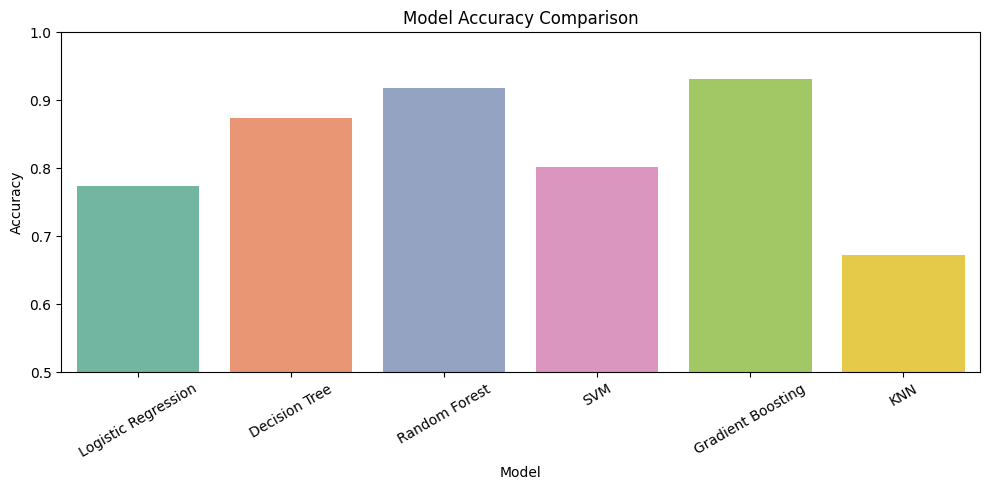


Best Model: Gradient Boosting (93.08%)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Models define
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM':                 SVC(class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier()
}

# Step 2: Train, Predict, Evaluate
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

# Step 3: Comparison Table
print("\nMODEL COMPARISON:")
results_df = pd.DataFrame(list(results.items()),
                           columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
print(results_df.to_string(index=False))

# Step 4: Accuracy Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()),
            y=list(results.values()),
            palette='Set2')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

# Step 5: Best Model
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} ({results[best_model]*100:.2f}%)")

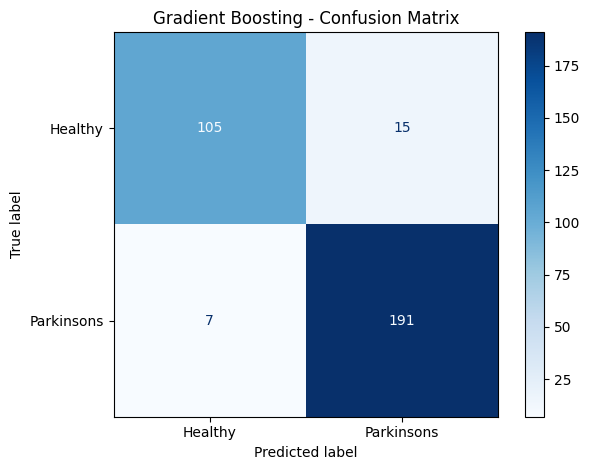

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

best = GradientBoostingClassifier(random_state=42)
best.fit(X_train_scaled, y_train)
y_pred_best = best.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Healthy', 'Parkinsons'],
    cmap='Blues'
)
plt.title('Gradient Boosting - Confusion Matrix')
plt.tight_layout()
plt.show()

Top 10 Important Features:
             Feature  Importance
               UPDRS    0.361406
FunctionalAssessment    0.153651
              Tremor    0.144692
                MoCA    0.075814
        Bradykinesia    0.073584
            Rigidity    0.067214
 PosturalInstability    0.044874
                 Age    0.019837
          SystolicBP    0.007635
      CholesterolLDL    0.006752


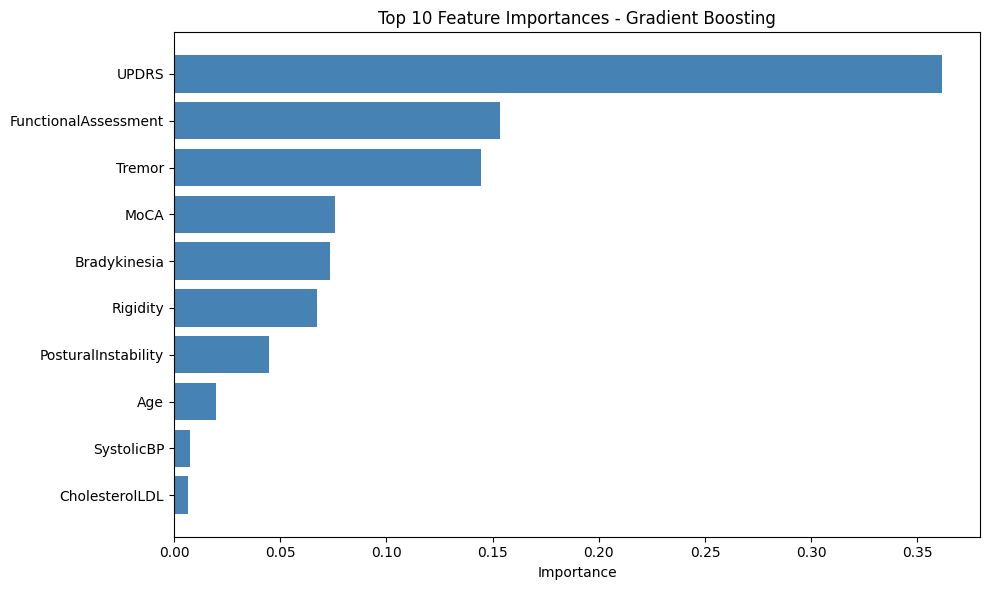

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
feature_names = X.columns.tolist()
importances = best.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

print("Top 10 Important Features:")
print(fi_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='steelblue')
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [29]:
import ipywidgets as widgets
from IPython.display import display

# Input fields
updrs = widgets.FloatText(description='UPDRS:', value=50.0)
functional = widgets.FloatText(description='Functional Assessment:', value=5.0)
tremor = widgets.Dropdown(description='Tremor:', options=[('No', 0), ('Yes', 1)])
moca = widgets.FloatText(description='MoCA:', value=25.0)
bradykinesia = widgets.Dropdown(description='Bradykinesia:', options=[('No', 0), ('Yes', 1)])
rigidity = widgets.Dropdown(description='Rigidity:', options=[('No', 0), ('Yes', 1)])
postural = widgets.Dropdown(description='Postural Instability:', options=[('No', 0), ('Yes', 1)])
age = widgets.IntText(description='Age:', value=60)
systolic = widgets.IntText(description='Systolic BP:', value=120)
cholesterol = widgets.FloatText(description='Cholesterol LDL:', value=100.0)

button = widgets.Button(description='Predict', button_style='primary')
output_result = widgets.Output()

def predict_patient(b):
    with output_result:
        output_result.clear_output()

        # Sample row from dataset
        sample = X_test.iloc[0].copy()

        # User values update karo
        sample['UPDRS'] = updrs.value
        sample['FunctionalAssessment'] = functional.value
        sample['Tremor'] = tremor.value
        sample['MoCA'] = moca.value
        sample['Bradykinesia'] = bradykinesia.value
        sample['Rigidity'] = rigidity.value
        sample['PosturalInstability'] = postural.value
        sample['Age'] = age.value
        sample['SystolicBP'] = systolic.value
        sample['CholesterolLDL'] = cholesterol.value

        # Scale aur predict
        sample_scaled = scaler.transform([sample.values])
        pred = best.predict(sample_scaled)[0]
        prob = best.predict_proba(sample_scaled)[0]

        if pred == 1:
            print("Result: PARKINSON'S DETECTED")
            print(f"Confidence: {prob[1]*100:.1f}%")
        else:
            print("Result: HEALTHY")
            print(f"Confidence: {prob[0]*100:.1f}%")

button.on_click(predict_patient)

display(updrs, functional, tremor, moca, bradykinesia,
        rigidity, postural, age, systolic, cholesterol,
        button, output_result)

FloatText(value=50.0, description='UPDRS:')

FloatText(value=5.0, description='Functional Assessment:')

Dropdown(description='Tremor:', options=(('No', 0), ('Yes', 1)), value=0)

FloatText(value=25.0, description='MoCA:')

Dropdown(description='Bradykinesia:', options=(('No', 0), ('Yes', 1)), value=0)

...

IntText(value=60, description='Age:')

IntText(value=120, description='Systolic BP:')

FloatText(value=100.0, description='Cholesterol LDL:')

Button(button_style='primary', description='Predict', style=ButtonStyle())

Output()

In [30]:
import joblib

joblib.dump(best, 'model_tabular.pkl')
joblib.dump(scaler, 'scaler_tabular.pkl')

from google.colab import files
files.download('model_tabular.pkl')
files.download('scaler_tabular.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>